In [136]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [137]:
df = pd.read_csv('multiple_linear_regression_dataset.csv')
df.head()

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [138]:
df.shape

(20, 3)

In [139]:
# Split the data into features and target variable
X = df.drop(columns="income")
y = df["income"]

In [140]:
# train - test splitting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [141]:
# applying linear regression
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [142]:
y_pred = reg.predict(X_test)

In [143]:
from sklearn.metrics import r2_score
r2_score(y_pred, y_test)

0.9657095084782386

In [144]:
reg.coef_

array([-112.90361382, 2202.45539341])

In [145]:
reg.intercept_

np.float64(31435.723212664954)

## Creating my own multiple linear regression class

In [146]:
class mymlr:

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X_train, y_train):
        X_train = np.insert(X_train.values, 0, 1, axis=1)
        beta = np.linalg.inv(np.dot(X_train.T, X_train)).dot(X_train.T).dot(y_train)
        self.coef_ = beta[1:]
        self.intercept_ = beta[0]

    def predict(self,X_test):
        y_pred = np.dot(X_test,self.coef_) + self.intercept_
        return y_pred
    

In [147]:
my_reg = mymlr()
my_reg.fit(X_train, y_train)
y_pred1 = my_reg.predict(X_test)


In [148]:
my_reg.coef_

array([-112.90361382, 2202.45539341])

In [149]:
my_reg.intercept_

np.float64(31435.723212664496)

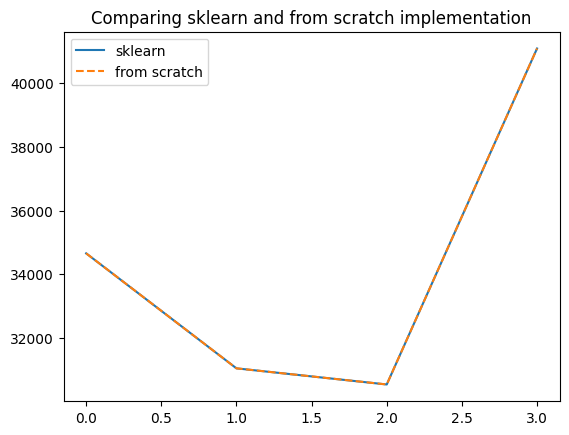

In [150]:
# comparing the sklearn and from scratch implementation

plt.plot(y_pred)
plt.plot(y_pred1, '--')
plt.title("Comparing sklearn and from scratch implementation")
plt.legend(["sklearn", "from scratch"])
plt.show()